In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import torch
import cv2
import pytesseract

import numpy as np
import pandas as pd
import copy
import os
import glob

import datetime as dt
import time
from timethis import timethis
import subprocess
from common_params import parent_directory_images, parent_directory_url_csvs
from preprocess_data_fns import (
    create_image_files_df, get_predicted_categories_clip, categorize_and_plot, categories,
    crop_out_text, banner_text_box, preprocess_image_for_banner_text

)


In [2]:
output_filename_rules = f'{parent_directory_url_csvs}df_clip_categorize_rules.csv'
output_filename_croppped = f'{parent_directory_url_csvs}df_clip_categorize_cropped.csv'

In [3]:

df=pd.read_csv(output_filename_rules)
print(df.shape)
print(df['is_exterior'].mean())
print(df['reason'].value_counts())
df['cropped_image_exists']=0
df.head()

(25913, 13)
0.33863311851194383
reason
pct_exterior>=70             7571
advert & pct_exterior>=50    1204
Name: count, dtype: int64


,filepath,filename,make,model,vehicle_id,is_car_exterior,top_category,probs_dict,probs_dict2,pct_exterior,is_exterior,reason,top3_categories,cropped_image_exists
0,/Users/levgolod/Projects/car_classifier/data/a...,20f1aa5ef85b48f7ac676a1e82147582.jpg,bmw,3-series,701932606,0.0,car exterior,"{'car exterior': 0.44714555, 'car interior': 0...","{'car exterior': 0.44714555, 'car interior': 0...",0.45,0,NaN,"['car exterior', 'car interior', 'car key']",0
1,/Users/levgolod/Projects/car_classifier/data/a...,376e2b73f7e04c0abb53dbed174a7bc8.jpg,bmw,3-series,701932606,1.0,car exterior,"{'car exterior': 0.8252363, 'advertisement': 0...","{'car exterior': 0.8252363, 'advertisement': 0...",0.83,1,pct_exterior>=70,"['car exterior', 'advertisement', 'gear select...",0
2,/Users/levgolod/Projects/car_classifier/data/a...,6f01890791f24dd69ccc70aff90cd73c.jpg,bmw,3-series,701932606,0.0,dashboard,"{'dashboard': 0.4605527, 'steering wheel': 0.2...","{'dashboard': 0.4605527, 'steering wheel': 0.2...",0.04,0,NaN,"['dashboard', 'steering wheel', 'gear selector']",0
3,/Users/levgolod/Projects/car_classifier/data/a...,ac2d692d18f64c6b9eb4835d24bd42eb.jpg,bmw,3-series,701932606,1.0,car exterior,"{'car exterior': 0.7926975, 'advertisement': 0...","{'car exterior': 0.7926975, 'advertisement': 0...",0.79,1,pct_exterior>=70,"['car exterior', 'advertisement', 'gear select...",0
4,/Users/levgolod/Projects/car_classifier/data/a...,b4ade0a7c1c5426496acf7b3d45eb8d5.jpg,bmw,3-series,701932606,1.0,car exterior,"{'car exterior': 0.96773624, 'advertisement': ...","{'car exterior': 0.96773624, 'advertisement': ...",0.97,1,pct_exterior>=70,"['car exterior', 'advertisement', 'wheels clos...",0


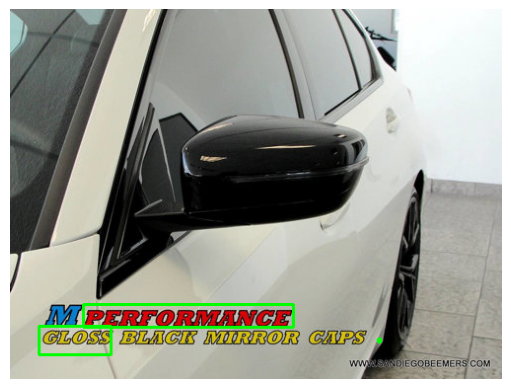

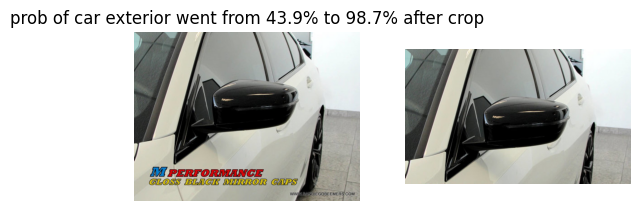

/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-728101019/65b9c8cb3af64c7581442421e0420839_cropped.jpg


In [4]:
## look at one interactive example
# example w multiple rows of text
image_path='/Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-728101019/65b9c8cb3af64c7581442421e0420839.jpg'
data = banner_text_box(image_path, preprocess_image_for_banner_text, plot=True, margin=25)
cropping_result =  crop_out_text(image_path, plot=True,margin=25)

if cropping_result['probs_diff'] >= 0.05 and cropping_result['probs_diff'] >= 0.50:
    newfile = image_path.replace('.jpg','_cropped.jpg')
    cv2.imwrite(newfile, cv2.cvtColor(cropping_result['cropped_image'], cv2.COLOR_RGB2BGR))

print(newfile)

0 2025-02-25 10:30:43.363101

0


1



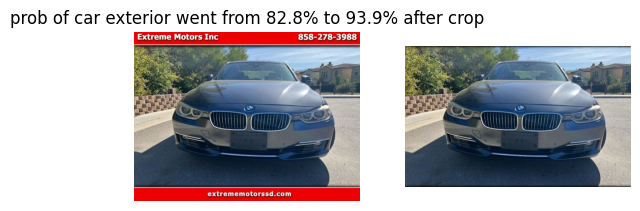

saving /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-701932606/376e2b73f7e04c0abb53dbed174a7bc8_cropped.jpg

2


3


4



In [5]:

plot=True
for index, row in df.head().iterrows():
    if index % 100 ==0:
        print(index, dt.datetime.now())

    print(f'\n{index}\n')
    if row['is_exterior']==1:
        image_path = row['filepath']
        cropping_result =  crop_out_text(image_path, plot=plot)
        if cropping_result['cropped_image'] is None:
            continue
        if cropping_result['probs_diff'] >= 0.05 and cropping_result['probs_after'] >= 0.50:
            df.loc[index, 'cropped_image_exists'] = 1
            newfile = image_path.replace('.jpg','_cropped.jpg')
            print(f'saving {newfile}')
            cv2.imwrite(newfile, cv2.cvtColor(cropping_result['cropped_image'], cv2.COLOR_RGB2BGR))



In [6]:
# for image_path in df.loc[df['is_exterior']==1, 'filepath']:
plot=False
for index, row in df.iterrows():
    if index % 100 ==0:
        print(index, dt.datetime.now())

    if row['is_exterior']==1:
        image_path = row['filepath']
        cropping_result =  crop_out_text(image_path, plot=plot)
        if cropping_result['cropped_image'] is None:
            continue
        if cropping_result['probs_diff'] >= 0.05 and cropping_result['probs_after'] >= 0.50:
            df.loc[index, 'cropped_image_exists'] = 1
            newfile = image_path.replace('.jpg','_cropped.jpg')
            print(f'saving {newfile}')
            cv2.imwrite(newfile, cv2.cvtColor(cropping_result['cropped_image'], cv2.COLOR_RGB2BGR))



0 2025-02-25 10:30:46.250649
saving /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-701932606/376e2b73f7e04c0abb53dbed174a7bc8_cropped.jpg
saving /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-723119018/a2fda90ca0c94ad7919589d4befa6d2f_cropped.jpg
saving /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-723119018/b17e6585beff4d8680b40bf07dc9c264_cropped.jpg
saving /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-723119018/d455931d6548412baeb7763af7e84418_cropped.jpg
saving /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-723119018/d97988a690104a85a295c7b1de45985b_cropped.jpg
saving /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/make-bmw/model-3-series/vehicle_id-723119018/e32b82fb

In [7]:
df.to_csv(output_filename_croppped, index=False)

In [8]:
!find  /Users/levgolod/Projects/car_classifier/data/autotrader/vehicle_images/ -type f -name '*_cropped.jpg' | wc -l

     538
